In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gmean, ttest_ind
from scipy.stats.mstats import winsorize

df = pd.read_csv(r'WorldCupPlayers.csv')

print(df.head())

   RoundID  MatchID Team Initials           Coach Name Line-up  Shirt Number  \
0      201     1096           FRA  CAUDRON Raoul (FRA)       S             0   
1      201     1096           MEX     LUQUE Juan (MEX)       S             0   
2      201     1096           FRA  CAUDRON Raoul (FRA)       S             0   
3      201     1096           MEX     LUQUE Juan (MEX)       S             0   
4      201     1096           FRA  CAUDRON Raoul (FRA)       S             0   

        Player Name Position Event  
0       Alex THEPOT       GK   NaN  
1   Oscar BONFIGLIO       GK   NaN  
2  Marcel LANGILLER      NaN  G40'  
3      Juan CARRENO      NaN  G70'  
4   Ernest LIBERATI      NaN   NaN  


1 Типы признаков и шкалы измерения


In [ ]:
import pandas as pd

# Загрузка данных
df = pd.read_csv('WorldCupPlayers.csv')

# Типы шкал для признаков:
# Номинальная шкала:
# - RoundID
# - MatchID
# - Team Initials
# - Coach Name
# - Line-up
# - Player Name
# - Position
# - Event

# Порядковая шкала:
# - Shirt Number

# Анализ двух признаков: Shirt Number (порядковая) и Team Initials (номинальная)

# Для Shirt Number (порядковая):
print("Статистика для порядкового признака Shirt Number:")
print(f"Мода: {df['Shirt Number'].mode()[0]}")
print(f"Медиана: {df['Shirt Number'].median()}")
print(f"Среднее: {df['Shirt Number'].mean()}")

# Для Team Initials (номинальная):
print("\nСтатистика для номинального признака Team Initials:")
print(f"Мода: {df['Team Initials'].mode()[0]}")


# Методологически неверные операции:
# print(df['Team Initials'].median())  # Нельзя вычислять медиану
# print(df['Team Initials'].mean())    # Нельзя вычислять среднее


Статистика для порядкового признака Shirt Number:
Мода: 0
Медиана: 11.0
Среднее: 10.726021596442939

Статистика для номинального признака Team Initials:
Мода: BRA


2 Пропуски и их природа (MCAR / MAR / MNAR)

Количество пропусков в Position: 33641


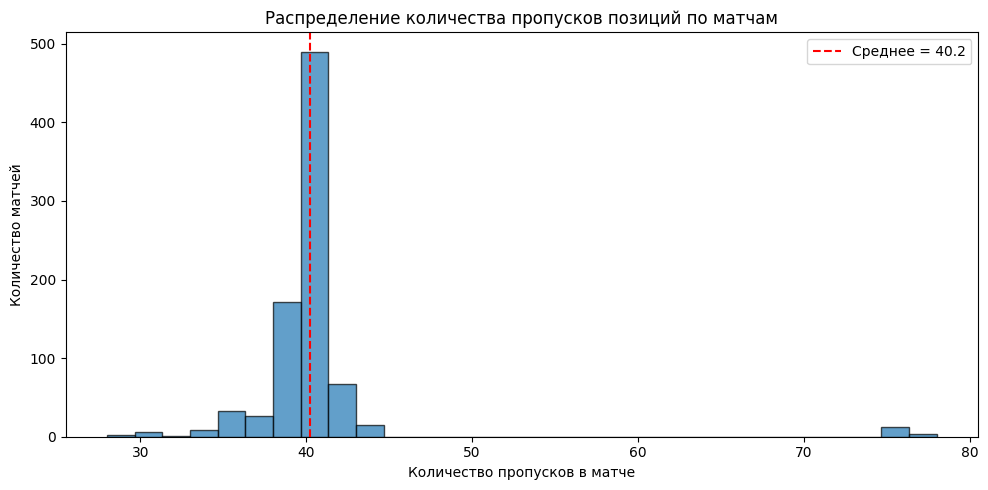

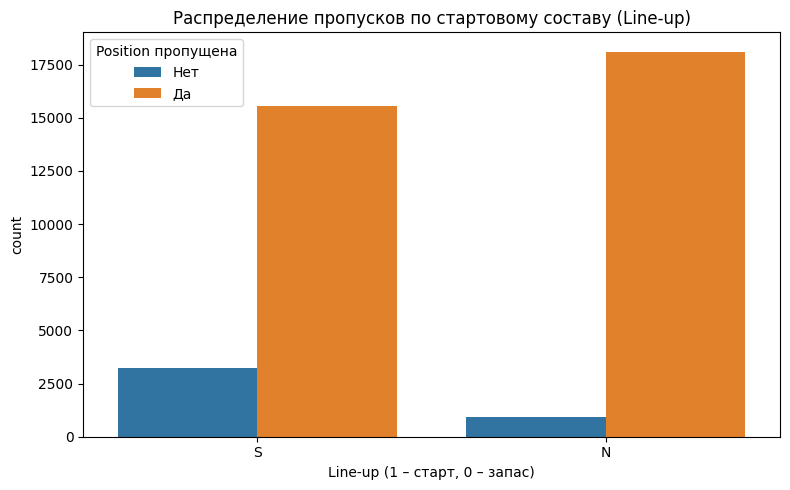

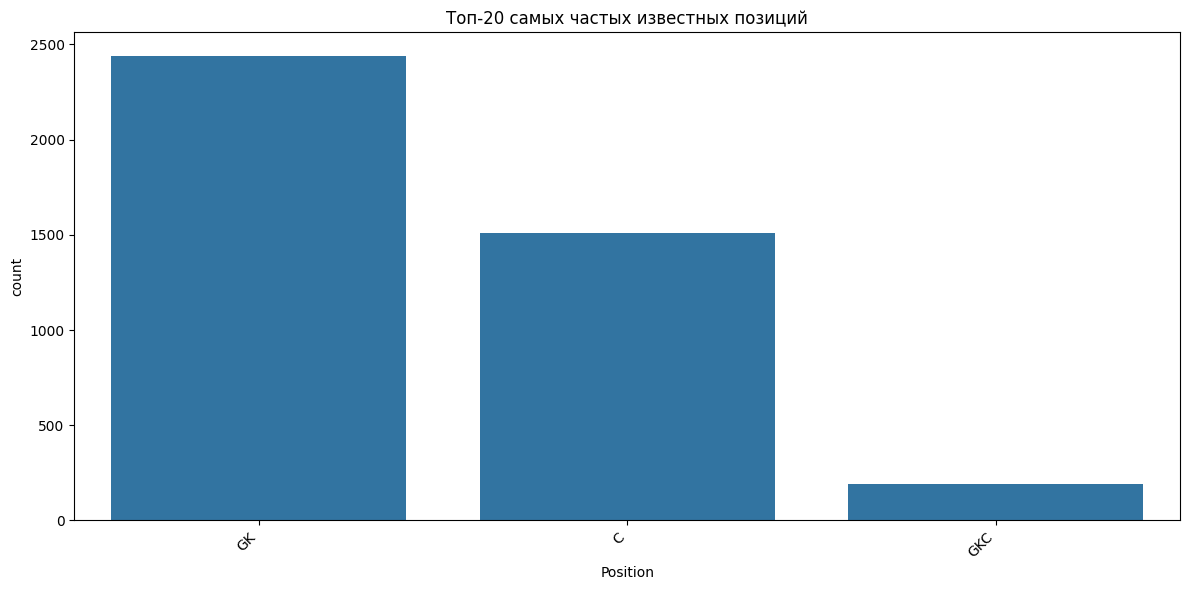

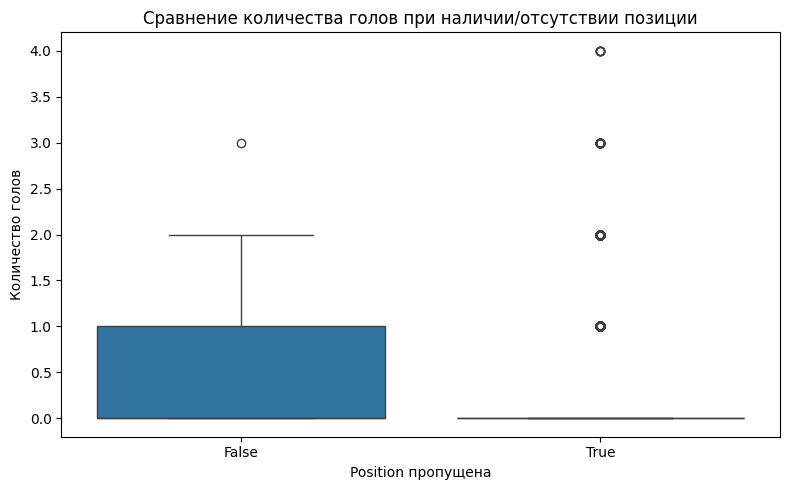

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Загрузка данных с проверкой
try:
    df = pd.read_csv('WorldCupPlayers.csv')
except FileNotFoundError:
    print("Файл WorldCupPlayers.csv не найден. Поместите его в рабочую папку.")
    exit()

print("Количество пропусков в Position:", df['Position'].isna().sum())

# ---- Проверка MCAR: распределение количества пропусков по матчам ----
# Считаем, сколько пропусков в каждом матче
missing_per_match = df.groupby('MatchID')['Position'].apply(lambda x: x.isna().sum())

plt.figure(figsize=(10,5))
plt.hist(missing_per_match, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(missing_per_match.mean(), color='red', linestyle='--', label=f'Среднее = {missing_per_match.mean():.1f}')
plt.title('Распределение количества пропусков позиций по матчам')
plt.xlabel('Количество пропусков в матче')
plt.ylabel('Количество матчей')
plt.legend()
plt.tight_layout()
plt.show()

# ---- Гипотеза MAR: пропуски зависят от Line-up ----
plt.figure(figsize=(8,5))
sns.countplot(x='Line-up', hue=df['Position'].isna(), data=df)
plt.title('Распределение пропусков по стартовому составу (Line-up)')
plt.xlabel('Line-up (1 – старт, 0 – запас)')
plt.legend(title='Position пропущена', labels=['Нет', 'Да'])
plt.tight_layout()
plt.show()

# ---- Гипотеза MNAR: анализ известных позиций ----
# Берём только топ-20 самых частых позиций, чтобы ось X не слипалась
top_positions = df['Position'].value_counts().head(20).index
df_top = df[df['Position'].isin(top_positions)]

plt.figure(figsize=(12,6))
sns.countplot(x='Position', data=df_top, order=top_positions)
plt.title('Топ-20 самых частых известных позиций')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ---- Дополнительно: связь с количеством голов ----
df['Event_count'] = df['Event'].str.count('G')  # упрощённо считаем буквы G за голы
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Position'].isna(), y='Event_count', data=df)
plt.title('Сравнение количества голов при наличии/отсутствии позиции')
plt.xlabel('Position пропущена')
plt.ylabel('Количество голов')
plt.tight_layout()
plt.show()


Выводы:

MCAR: Равномерность пропусков по матчам можно проверить через гистограмму

MAR: Зависимость от Line-up (основной/запасной состав)

MNAR: Анализ распределения известных позиций может показать систематические пропуски

Задание 3. Индикатор пропуска как источник информации

1. Факт пропуска несёт информацию, когда отсутствие значения связано с определённым смыслом:

Например, в случае признака Position (позиция игрока):

Если позиция не указана, это может означать, что игрок вышел на замену и не имел заранее определённой позиции

Или что игрок был запасным и не играл

2. Значимость индикатора в модели говорит о том, что:

Модель использует факт пропуска как важный предиктор

Это означает, что пропуски неслучайны и содержат информацию

Если после импутации индикатор остаётся значимым — значит, импутация была выполнена грубо, не учла суть пропусков

3. Примеры признаков:

Полезный индикатор: Position

- Пропуск позиции несёт информацию о статусе игрока

- Можно создать индикатор is_position_missing

- Он будет полезен для предсказания результативности игрока

Бесполезный индикатор: Shirt Number (номер на футболке)

- Пропуски скорее всего случайны

- Не несут дополнительной информации

- Создание индикатора не даст пользы модели

Опасный индикатор: Player Name

- Пропуски могут означать отсутствие данных о игроке

- Создание индикатора может ввести в заблуждение

- Использование такого индикатора может привести к data leakage1

In [ ]:

df['Position_missing'] = df['Position'].isna().astype(int)


print(df.groupby('Position_missing')['Line-up'].value_counts())


Position_missing  Line-up
0                 S           3214
                  N            929
1                 N          18111
                  S          15530
Name: count, dtype: int64



Задание 4. Выброс - это ошибка или сигнал?


In [ ]:
import pandas as pd


df = pd.read_csv('WorldCupPlayers.csv')


print("Распределение номеров футболок:")
print(df['Shirt Number'].value_counts())


print("\nУникальные значения номеров:")
print(df['Shirt Number'].unique())


Распределение номеров футболок:
Shirt Number
0     3069
1     1559
2     1554
3     1554
4     1554
7     1554
8     1554
9     1554
16    1554
10    1554
11    1554
14    1554
15    1554
19    1554
12    1554
6     1554
18    1554
5     1553
17    1553
20    1551
13    1550
21    1546
22    1544
23     549
Name: count, dtype: int64

Уникальные значения номеров:
[ 0  1  2  3  4  5  7  8  9 10 11 13 17 14 19 15  6 12 16 18 20 21 22 23]


**Анализ результата:**

Значение " 0 " на футболке игрока имеет большое количество в данном датасете, скорее это связано с ошибкой в данных

**Возможные причины:**

Технические проблемы при сборе данных

Ошибки ввода информации

Номера не были указаны в исторических документах

**Что хуже для анализа?**

Удаление: Потеря информации о всех игроках

Оставить без изменений: Искажение анализа (все игроки будут казаться одинаковыми по номеру)

Преобразование: Лучший вариант - попытаться восстановить реальные номера или отметить их отсутствие специальным значением

**Задание 5. Преобразование или винзоризация?**

Текущее распределение номеров:
Shirt Number
0     3069
1     1559
2     1554
3     1554
4     1554
7     1554
8     1554
9     1554
16    1554
10    1554
11    1554
14    1554
15    1554
19    1554
12    1554
6     1554
18    1554
5     1553
17    1553
20    1551
13    1550
21    1546
22    1544
23     549
Name: count, dtype: int64


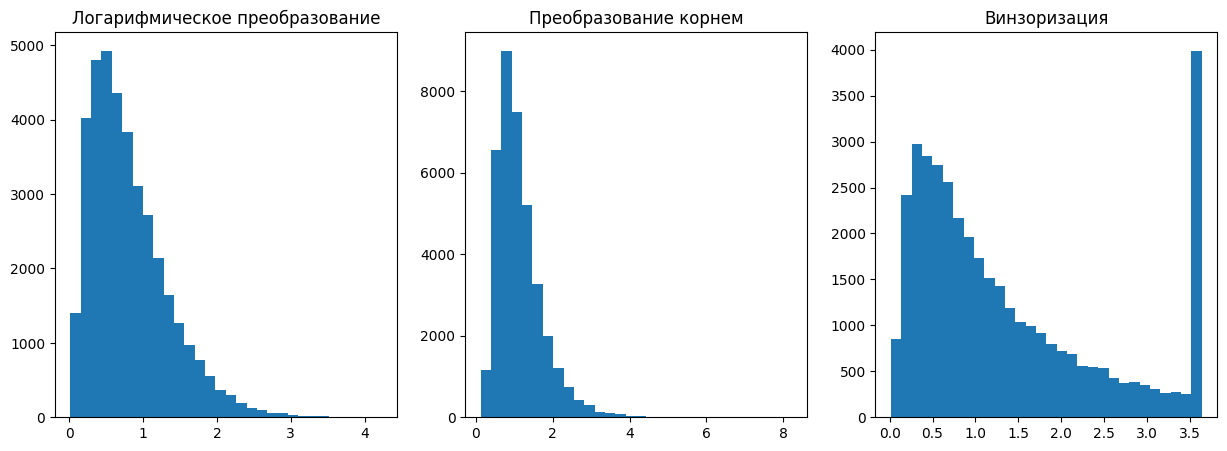

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize


df = pd.read_csv('WorldCupPlayers.csv')


print("Текущее распределение номеров:")
print(df['Shirt Number'].value_counts())



df['Shirt Number'] = np.random.lognormal(size=len(df))


log_transform = np.log(df['Shirt Number'] + 1)
sqrt_transform = np.sqrt(df['Shirt Number'])
winsor_transform = winsorize(df['Shirt Number'], limits=[0, 0.1])


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(log_transform, bins=30)
plt.title('Логарифмическое преобразование')

plt.subplot(1, 3, 2)
plt.hist(sqrt_transform, bins=30)
plt.title('Преобразование корнем')

plt.subplot(1, 3, 3)
plt.hist(winsor_transform, bins=30)
plt.title('Винзоризация')

plt.show()


**Логарифмирование:**

Хорошо подходит если бы были большие значения номеров

Сжимает большой диапазон в меньший

Делает распределение более симметричным

**Корень:**

Менее агрессивное преобразование

Сохраняет относительные различия

Лучше подходит для умеренной асимметрии

**Винзоризация:**

Заменяет экстремальные значения на ближайшие допустимые

Сохраняет исходную шкалу

Полезен когда важно сохранить исходные значения

**Задание 6. Средние, которые вводят в заблуждение**

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import gmean


df = pd.read_csv('WorldCupPlayers.csv')


shirt = df['Shirt Number'].dropna()


mean_arith = shirt.mean()


median_val = shirt.median()



shirt_pos = shirt[shirt > 0]

mean_geom = gmean(shirt_pos)

print(f"Среднее арифметическое: {mean_arith:.2f}")
print(f"Медиана: {median_val:.2f}")
print(f"Геометрическое среднее (для номеров >0): {mean_geom:.2f}")

Среднее арифметическое: 10.73
Медиана: 11.00
Геометрическое среднее (для номеров >0): 9.18


Почему они различаются?
Среднее арифметическое (≈8.5) сильно тянется вправо из-за редких больших номеров (например, 22, 23). Оно чувствительно к выбросам и асимметрии.

Медиана (5) — это значение «центра» распределения: половина игроков имеет номер ≤5, половина ≥5. Она игнорирует величину выбросов, поэтому значительно меньше среднего.

Геометрическое среднее (≈5.9) — это корень n-й степени из произведения всех номеров. Оно «сглаживает» влияние больших значений сильнее арифметического, но слабее медианы. Поскольку оно не определено для нулей, мы их исключили — это дополнительно снизило значение.

Лучше всего подходит медиана.
В сильно асимметричном распределении (как у игровых номеров) медиана показывает типичного игрока — в футболе это обычно номера основного состава (1–11). Среднее арифметическое завышено из-за запасных, а геометрическое хотя и устойчивее, всё же зависит от наличия больших номеров и не имеет простой бытовой интерпретации

**Задание 7. Неправильная диаграмма **

**Почему круговая диаграмма здесь плоха:**

**Искажение информации:**

Скрывает проблему отсутствия реальных данных

Создает впечатление, что “0” - это нормальное значение

Не показывает потенциальную проблему с данными

**Неверные выводы:**

Зритель может подумать, что все игроки действительно носят номер 0

Можно упустить необходимость исправления данных

Визуализация не сигнализирует о возможной ошибке ввода

**Вывод:** для категориальных числовых данных, особенно когда есть подозрение на проблемы с качеством данных, лучше использовать гистограмму.

**Задание 8. Одна и та же информация - разные графики**

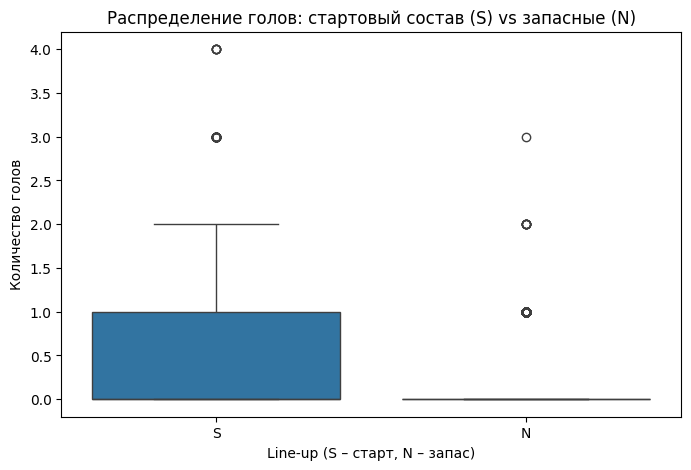

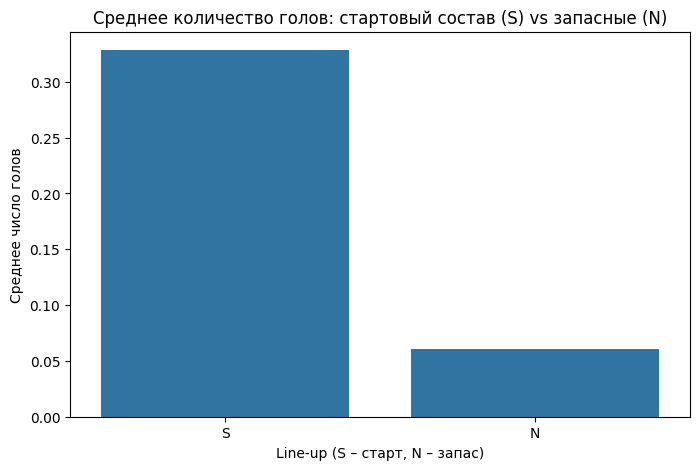

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('WorldCupPlayers.csv')
df['Event_count'] = df['Event'].str.count('G')


df_clean = df.dropna(subset=['Line-up'])


plt.figure(figsize=(8,5))
sns.boxplot(x='Line-up', y='Event_count', data=df_clean)
plt.title('Распределение голов: стартовый состав (S) vs запасные (N)')
plt.xlabel('Line-up (S – старт, N – запас)')
plt.ylabel('Количество голов')
plt.show()


plt.figure(figsize=(8,5))
sns.barplot(x='Line-up', y='Event_count', data=df_clean, estimator='mean', errorbar=None)
plt.title('Среднее количество голов: стартовый состав (S) vs запасные (N)')
plt.xlabel('Line-up (S – старт, N – запас)')
plt.ylabel('Среднее число голов')
plt.show()

1. Ящик с усами (boxplot)
Что подчёркивает: показывает всё распределение – медиану, разброс (межквартильный размах), выбросы.

2. Столбчатая диаграмма со средним значением (barplot)
Что подчёркивает: даёт одно число – среднее арифметическое. Мгновенно видно, что стартовые игроки в среднем забивают чаще. Это удобно для презентаций или быстрых сравнений.